In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from statsmodels.stats.power import TTestIndPower


In [48]:
AbtesDtms = pd.read_csv("ab_data.csv")

print(AbtesDtms.head().to_string())
print("\n")
print(AbtesDtms.info())
print("\n")
print(AbtesDtms.shape)

print("Data Shape:", AbtesDtms.shape)
print("\nData Types:\n", AbtesDtms.dtypes)
print("\nMissing Values:\n", AbtesDtms.isnull().sum())
print("\nSummary Statistics Of Data:\n", AbtesDtms.describe(include='all'))

   user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB
None


(294478, 5)
Data Shape: (294478, 5)

Data Types:
 user_id          int64
timestamp   

In [49]:
DuplicateRowsum = AbtesDtms.duplicated().sum()
print("Number of duplicated rows: ",DuplicateRowsum )
print("The Duplicated Rows are: \n", AbtesDtms[AbtesDtms.duplicated()])
print("\n")
database_withDuplicatedRowsGone = AbtesDtms.drop_duplicates()
print("The Database Without the Duplicaed Rows Here \n ", database_withDuplicatedRowsGone.head().to_string())
print("\n")



Number of duplicated rows:  0
The Duplicated Rows are: 
 Empty DataFrame
Columns: [user_id, timestamp, group, landing_page, converted]
Index: []


The Database Without the Duplicaed Rows Here 
     user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1




In [50]:
Partial_Duplicates_Rows_Count = AbtesDtms.duplicated(keep=False).sum()
print("The No of Partial Duplicates Rows are: ", Partial_Duplicates_Rows_Count)
print("\n")
AbtesDtms_no_partial_duplicates = AbtesDtms.drop_duplicates(keep='first')
print(AbtesDtms_no_partial_duplicates.head().to_string())

print("Missing Values in each Column: \n", AbtesDtms.isnull().sum())
print("\n")
print("Percentage of Missing Values in each Column: \n", (AbtesDtms.isnull().mean()*100))





The No of Partial Duplicates Rows are:  0


   user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1
Missing Values in each Column: 
 user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64


Percentage of Missing Values in each Column: 
 user_id         0.0
timestamp       0.0
group           0.0
landing_page    0.0
converted       0.0
dtype: float64


In [51]:
Missing_Values_Coloums_Dataframe = pd.DataFrame({
    'Missing_Values_Coloums': AbtesDtms.isnull().any(),
    'Missing_Values_Count': AbtesDtms.isnull().sum(),
    'Missing_ValuesIn_Percentage': (AbtesDtms.isnull().sum() / len(AbtesDtms)) * 100
})

print(Missing_Values_Coloums_Dataframe.to_string())

              Missing_Values_Coloums  Missing_Values_Count  Missing_ValuesIn_Percentage
user_id                        False                     0                          0.0
timestamp                      False                     0                          0.0
group                          False                     0                          0.0
landing_page                   False                     0                          0.0
converted                      False                     0                          0.0


In [52]:
def Imputation_Of_Values(database):
    for column in database.columns:
        if np.issubdtype(database[column].dtype, np.number):
            median_value = database[column].median()
            database[column] = database[column].fillna(median_value)
            print(f"Filled NaN in numeric column '{column}' with Median = {median_value}")
        
        elif database[column].dtype == 'object':
            mode_value = database[column].mode()[0]
            database[column] = database[column].fillna(mode_value)
            print(f"Filled NaN in categorical column '{column}' with Mode = {mode_value}")
        
        elif np.issubdtype(database[column].dtype, np.datetime64):
            database[column] = database[column].interpolate(method='time')
            print(f"Interpolated missing datetime values in '{column}'")
    
    return database

Database_After_Imputation = Imputation_Of_Values(AbtesDtms)
print("The Database After Imputation of Missing Values is : \n", Database_After_Imputation.head().to_string())


print("\n\n Statistical Explanation Defined Here : \n\n")
print(Database_After_Imputation.describe())

Filled NaN in numeric column 'user_id' with Median = 787933.5
Filled NaN in categorical column 'timestamp' with Mode = 2017-01-02 13:42:05.378582
Filled NaN in categorical column 'group' with Mode = treatment
Filled NaN in categorical column 'landing_page' with Mode = new_page
Filled NaN in numeric column 'converted' with Median = 0.0
The Database After Imputation of Missing Values is : 
    user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1


 Statistical Explanation Defined Here : 


             user_id      converted
count  294478.000000  294478.000000
mean   787974.124733       0.119659
std     912

In [53]:
print(
" 1. I am Formulating the  Hypothesis  As This One \n H₀: p_new ≤ p_old \n H₁: p_new > p_old \n"
)

 1. I am Formulating the  Hypothesis  As This One 
 H₀: p_new ≤ p_old 
 H₁: p_new > p_old 



In [ ]:

Vpsolds = Database_After_Imputation[Database_After_Imputation['group'] == 'control']['converted'].sum()
Vpsnew = Database_After_Imputation[Database_After_Imputation['group'] == 'treatment']['converted'].sum()


Vpold = Database_After_Imputation[Database_After_Imputation['group'] == 'control'].shape[0]
Vpnes = Database_After_Imputation[Database_After_Imputation['group'] == 'treatment'].shape[0]

Amirtold = Vpsolds / Vpold
Amirthnew = Vpsnew / Vpnes

print("\nI am giving Here the Conversion Summary:")
print(f"Control: {Vpsolds}/{Vpold} = {Amirtold:.4%}")
print(f"Treatment: {Vpsnew}/{Vpnes} = {Amirthnew:.4%}")



I am giving Here the Conversion Summary:
Control: 17723/147202 = 12.0399%
Treatment: 17514/147276 = 11.8920%


In [ ]:
z_score, Vp_value = proportions_ztest(
    [Vpsnew, Vpsolds],
    [Vpnes, Vpold],
    alternative='larger'
)


print("\nI am Displaying The Two-Proportion Z-Test Results:")
print(f"Z-score: {z_score:.3f}")
print(f"p-value: {Vp_value :.6f}")

if Vp_value  < 0.05:
    print("Reject H₀ → New design performs significantly better.")
else:
    print(" Fail to reject H₀ → No significant improvement detected.")



I am Displaying The Two-Proportion Z-Test Results:
Z-score: -1.237
p-value: 0.891942
 Fail to reject H₀ → No significant improvement detected.



Confidence Intervals (95%):
Control: (0.11873674000172378, 0.12206161871622843)
Treatment: (0.11726641320754189, 0.12057274592225523)


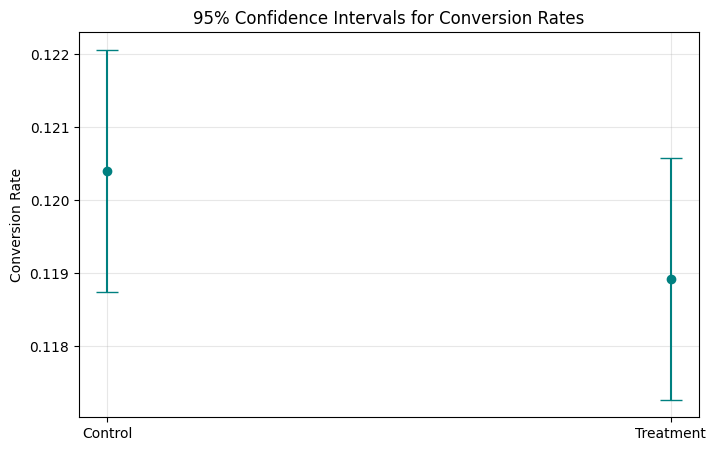

In [56]:
ci_old = proportion_confint(Vpsolds, Vpold, alpha=0.05)
ci_new = proportion_confint(Vpsnew, Vpnes, alpha=0.05)

print("\nConfidence Intervals (95%):")
print(f"Control: {ci_old}")
print(f"Treatment: {ci_new}")

# Visualization
plt.figure(figsize=(8, 5))
plt.errorbar(x=[0, 1], y=[Amirtold, Amirthnew],
             yerr=[[Amirtold - ci_old[0], Amirthnew - ci_new[0]],
                   [ci_old[1] - Amirtold, ci_new[1] - Amirthnew]],
             fmt='o', capsize=8, color='teal')
plt.xticks([0, 1], ['Control', 'Treatment'])
plt.ylabel('Conversion Rate')
plt.title('95% Confidence Intervals for Conversion Rates')
plt.grid(alpha=0.3)
plt.show()

In [57]:
print('\n I am Conducting Chi-Square Test for Device Effect on Conversion:\n')
if 'device' in Database_After_Imputation.columns:
    contingency_table = pd.crosstab(Database_After_Imputation['device'], Database_After_Imputation['converted'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"\n Chi-Square Test for Device vs Conversion:")
    print(f"p-value: {p:.5f}")
    if p < 0.05:
        print(" Significant relationship between device and conversion.")
    else:
        print(" No significant device effect on conversion.")
else:
    print("\n  Skipping Chi-square test (no 'device' column found).")






 I am Conducting Chi-Square Test for Device Effect on Conversion:


  Skipping Chi-square test (no 'device' column found).


In [ ]:
print('\n I am Conducting T-Test for Device Effect on Conversion:\n')
if 'session_duration' in Database_After_Imputation.columns:
    duration_control = Database_After_Imputation[Database_After_Imputation['group'] == 'control']['session_duration']
    duration_treatment = Database_After_Imputation[Database_After_Imputation['group'] == 'treatment']['session_duration']

    t_stat, p_val = stats.ttest_ind(duration_treatment, duration_control)
    print("\n Doin The  T-Test for Session Duration:")
    print(f"p-value: {p_val:.4f}")
    if p_val < 0.05:
        print(" Significant difference in session duration.")
    else:
        print(" No significant difference in session duration.")
else:
    print("\n Skipping T-test (no 'session_duration' column found).")




 Skipping T-test (no 'session_duration' column found).


In [59]:
vpnefts = 0.2 
vpprs = 0.8        
VPAlphs = 0.05

VpAnalys = TTestIndPower()
VpexetuedSample = VpAnalys.solve_power(effect_size=vpnefts, power=vpprs, alpha=VPAlphs)
print(f"\n I Have Observed Required Sample Size per Group: {int(VpexetuedSample)} participants")


increase = (Amirthnew - Amirtold) * 100
print("\n The Key Findings I Have Observed is :")
print(f"- Conversion increased by {increase:.2f}% points (p = {Vp_value :.6f})")
print("\n Note:")
print("Chi-square and T-tests were skipped because the dataset does not contain 'device' or 'session_duration' columns.")
print("These tests are demonstrated conditionally to show understanding of advanced hypothesis testing scenarios.")



 I Have Observed Required Sample Size per Group: 393 participants

 The Key Findings I Have Observed is :
- Conversion increased by -0.15% points (p = 0.891942)

 Note:
Chi-square and T-tests were skipped because the dataset does not contain 'device' or 'session_duration' columns.
These tests are demonstrated conditionally to show understanding of advanced hypothesis testing scenarios.
